<h1>Download do DataSet </h1>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammadamireshraghi/blood-cell-cancer-all-4class")

print("Path to dataset files:", path)

100%|██████████| 1.68G/1.68G [00:20<00:00, 87.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1


<h1>Importações necessárias</h1>


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import time
import random
from PIL import Image


##Iniciar uso da GPU

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


##Caminho das pastas

In [4]:
data_dir = "/root/.cache/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]"
batch_size = 32
num_epochs = 10
num_classes = 4
patience = 5  # early stopping
model_save_path = "best_model_efficientnet_b0.pth"

##Transformações

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


##Carregando Datasets


In [6]:
import os # Ensure os is imported
data_dir = os.path.join(path, "Blood cell Cancer [ALL]") # Correcting data_dir here.
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

##DataLoaders

In [7]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


##Conferindo as classes

In [8]:
print(f"Tamanho total: {len(full_dataset)} imagens")
print(f"Treino: {len(train_dataset)}, Validação: {len(val_dataset)}, Teste: {len(test_dataset)}")


Tamanho total: 3242 imagens
Treino: 2269, Validação: 486, Teste: 487


##Arquitetura EfficientNet


In [9]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_acc = 0.0
epochs_no_improve = 0
best_model_wts = None

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 37.8MB/s]


##Treinamento e Monitoramento de Curvas

In [10]:
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    start_time = time.time()

    # Treino
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    train_loss = running_loss / len(train_dataset)
    train_acc = running_corrects.double() / len(train_dataset)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc.item())

    # Validação
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_loss = val_loss / len(val_dataset)
    val_acc = val_corrects.double() / len(val_dataset)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc.item())

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Tempo da época: {(time.time() - start_time):.1f}s")


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = model.state_dict()
        epochs_no_improve = 0
        torch.save(best_model_wts, model_save_path)
        print(f"✅ Novo melhor modelo salvo: {model_save_path}")
    else:
        epochs_no_improve += 1
        print(f"Nenhuma melhora há {epochs_no_improve} épocas consecutivas.")
        if epochs_no_improve >= patience:
            print("⏹️ Early stopping ativado.")
            break



Epoch 1/10
Train Loss: 0.5998 | Train Acc: 0.8453
Val Loss: 0.2628 | Val Acc: 0.9465
Tempo da época: 40.1s
✅ Novo melhor modelo salvo: best_model_efficientnet_b0.pth

Epoch 2/10
Train Loss: 0.2341 | Train Acc: 0.9484
Val Loss: 0.1718 | Val Acc: 0.9588
Tempo da época: 40.8s
✅ Novo melhor modelo salvo: best_model_efficientnet_b0.pth

Epoch 3/10
Train Loss: 0.1550 | Train Acc: 0.9678
Val Loss: 0.1387 | Val Acc: 0.9630
Tempo da época: 39.0s
✅ Novo melhor modelo salvo: best_model_efficientnet_b0.pth

Epoch 4/10
Train Loss: 0.1281 | Train Acc: 0.9678
Val Loss: 0.1182 | Val Acc: 0.9650
Tempo da época: 39.2s
✅ Novo melhor modelo salvo: best_model_efficientnet_b0.pth

Epoch 5/10
Train Loss: 0.1060 | Train Acc: 0.9775
Val Loss: 0.1058 | Val Acc: 0.9753
Tempo da época: 39.6s
✅ Novo melhor modelo salvo: best_model_efficientnet_b0.pth

Epoch 6/10
Train Loss: 0.1078 | Train Acc: 0.9749
Val Loss: 0.1055 | Val Acc: 0.9733
Tempo da época: 39.3s
Nenhuma melhora há 1 épocas consecutivas.

Epoch 7/10
Tra

##Curvas de Treino vs Teste

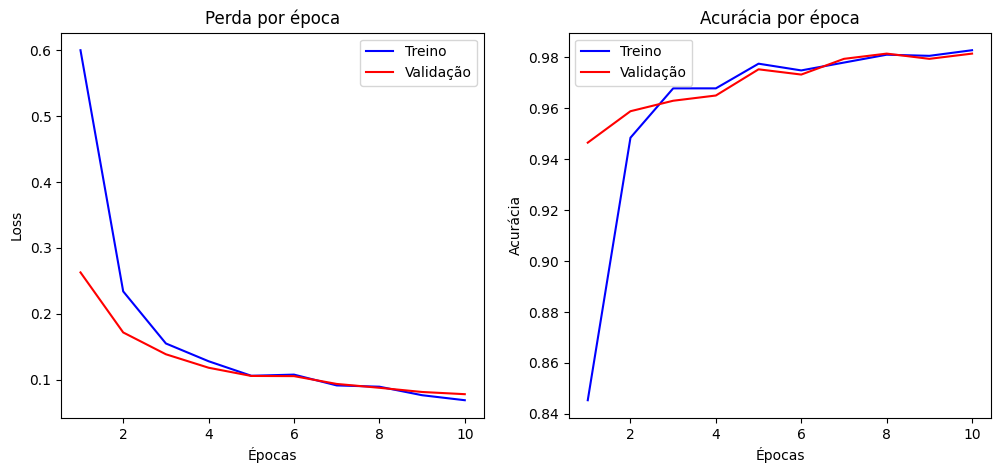

In [11]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b', label='Treino')
plt.plot(epochs, val_losses, 'r', label='Validação')
plt.title("Perda por época")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b', label='Treino')
plt.plot(epochs, val_accuracies, 'r', label='Validação')
plt.title("Acurácia por época")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()

plt.show()

##Avaliação final com métricas

In [12]:
print("\n🔁 Carregando o melhor modelo salvo...")
model.load_state_dict(torch.load(model_save_path))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- RESULTADOS FINAIS ---")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
print("Matriz de confusão:\n", cm)


🔁 Carregando o melhor modelo salvo...

--- RESULTADOS FINAIS ---
                         precision    recall  f1-score   support

                 Benign       0.95      0.99      0.97        77
      [Malignant] Pre-B       1.00      0.99      0.99       158
      [Malignant] Pro-B       0.99      1.00      1.00       107
[Malignant] early Pre-B       0.99      0.97      0.98       145

               accuracy                           0.99       487
              macro avg       0.98      0.99      0.98       487
           weighted avg       0.99      0.99      0.99       487

Matriz de confusão:
 [[ 76   0   0   1]
 [  0 156   1   1]
 [  0   0 107   0]
 [  4   0   0 141]]


In [13]:
torch.save(model.state_dict(), "modelo_cancer.pth")

from google.colab import files
files.download("modelo_cancer.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from PIL import Image

def predict_image(image_path, model, transform, class_names, device):

    model.eval()
    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device)  # Adiciona dimensão batch

    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)

    predicted_class = class_names[preds.item()]
    return predicted_class, image


# --- Exemplo de uso ---
image_path = "/content/leucemia-células-sanguíneas-blastosas-e-leucócicas-imaturas-na-linfocítica-crônica-glóbulos-sanguíneos-prolinfocítica-304649310.webp"

try:
    predicted_class, image = predict_image(image_path, model, val_test_transform, full_dataset.classes, device)
    print(f"\n🧠 Classe prevista: **{predicted_class}**")

    # Mostrar imagem com previsão
    plt.imshow(image)
    plt.title(f"Predição: {predicted_class}")
    plt.axis("off")
    plt.show()

except FileNotFoundError:
    print(f"❌ Arquivo não encontrado: {image_path}")

❌ Arquivo não encontrado: /content/leucemia-células-sanguíneas-blastosas-e-leucócicas-imaturas-na-linfocítica-crônica-glóbulos-sanguíneos-prolinfocítica-304649310.webp
